In [27]:
import glob
import pandas as pd
import matplotlib.pyplot as plt


In [28]:
# 1. Busca os arquivos exatos de 15 pets e 18 treinos
file_anamnese = glob.glob('*anamnese*15*pets*.csv')
file_treinos = glob.glob('*treinos*18*reg*.csv')

# Se não achar pelos nomes compridos, pega qualquer um que tenha 'anamnese' e 'treino'
if not file_anamnese:
    file_anamnese = [f for f in glob.glob('*anamnese*.csv')]
if not file_treinos:
    file_treinos = [f for f in glob.glob('*treino*.csv')]

print(f"Arquivo Anamnese selecionado: {file_anamnese}")
print(f"Arquivo Treinos selecionado:  {file_treinos}")


Arquivo Anamnese selecionado: ['conectapet_anamnese_15_pets_2026-09-09.csv']
Arquivo Treinos selecionado:  ['conectapet_treinos.csv']


In [29]:
# 2. Carrega os DataFrames
df_pets = pd.read_csv(file_anamnese[0])
df_treinos = pd.read_csv(file_treinos[0])

print(f"\n✅ SUCESSO ABSOLUTO!")
print(f"• Total de Pets carregados:    {len(df_pets)}")
print(f"• Total de Treinos carregados: {len(df_treinos)}")



✅ SUCESSO ABSOLUTO!
• Total de Pets carregados:    15
• Total de Treinos carregados: 18


In [30]:
# 3. KPIs
media_nota = df_treinos['Nota_Desempenho_1a5'].mean()
total_min = df_treinos['Duracao_Minutos'].sum()
total_moedas = df_treinos['Petcoins_Ganhas'].sum()

print("\n" + "="*50)
print("🐾 CONECTAPET - EXECUTIVE METRICS")
print("="*50)
print(f"⭐ Média Geral de Desempenho: {media_nota:.2f} / 5.0 estrelas")
print(f"⏱️ Tempo Total de Treinos:    {total_min:.1f} minutos ({total_min/60:.1f} horas)")
print(f"🪙 Total de PETCOINS Geradas: {total_moedas} moedas")


🐾 CONECTAPET - EXECUTIVE METRICS
⭐ Média Geral de Desempenho: nan / 5.0 estrelas
⏱️ Tempo Total de Treinos:    0.0 minutos (0.0 horas)
🪙 Total de PETCOINS Geradas: 0.0 moedas


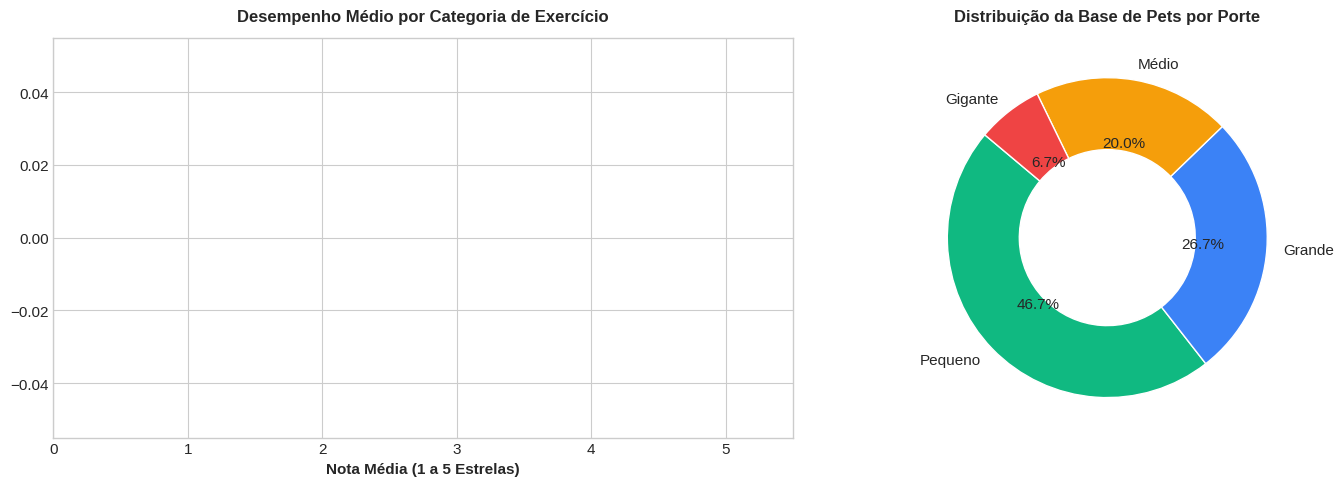

In [31]:
# 4. Geração dos Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Média de Desempenho por Categoria
cat_perf = df_treinos.groupby('Categoria_Exercicio')['Nota_Desempenho_1a5'].mean().sort_values()
bars = axes[0].barh(cat_perf.index, cat_perf.values, color='#4F46E5', height=0.55)
axes[0].set_title('Desempenho Médio por Categoria de Exercício', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Nota Média (1 a 5 Estrelas)', fontweight='bold')
axes[0].set_xlim(0, 5.5)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.08, bar.get_y() + bar.get_height()/2, f'{w:.2f} ★', va='center', fontweight='bold', color='#312E81')

  # Gráfico 2: Distribuição dos Pets por Porte
porte_counts = df_pets['Porte'].value_counts()
colors = ['#10B981', '#3B82F6', '#F59E0B', '#EF4444']
axes[1].pie(porte_counts, labels=porte_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops=dict(width=0.45, edgecolor='white'))
axes[1].set_title('Distribuição da Base de Pets por Porte', fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

In [33]:
# 5. Top Desafios Comportamentais
print("\n🧠 TOP 5 DESAFIOS COMPORTAMENTAIS MAIS RELATADOS:")
desafios = df_pets['Desafios_Comportamentais'].dropna().str.split('; ').explode().value_counts()
for i, (desafio, qtd) in enumerate(desafios.head(5).items(), 1):
    print(f" {i}. {desafio} ({qtd} pets)")


🧠 TOP 5 DESAFIOS COMPORTAMENTAIS MAIS RELATADOS:
 1. Puxar muito na guia no passeio (1 pets)
 2. Pular nas visitas para pedir atenção (1 pets)
 3. Ansiedade por separação (uivos ao ficar só) (1 pets)
 4. Latidos excessivos na campainha (1 pets)
 5. Reatividade com outros cães na guia (1 pets)
